In [1]:
from zipfile import ZipFile
from typing import List, Dict
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score,roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import FunctionTransformer

In [2]:
zip_path = "Downloads/VDJdb_PosNeg_corrected_onehot_pca_umap_kmeans_esm.csv.zip"
label_col = "binding"
drop_cols = ["unnamed: 0", "vdjdb.score", "complex.id"] #, "kmeans_cluster", "esmkmeans_cluster"]   
test_size = 0.20
top_k = 200
random_state = 42
c_val = 1.0
max_iter = 5000
class_weight = "balanced"

In [3]:
# logistic regression hyperparams
lr_preselect_n = 1000
lr_solver = "lbfgs"
lr_c_val = 0.5
lr_tol = 1e-3
lr_max_iter = 1000
lr_class_weight = "balanced"

# random forest hyperparams
rf_n_estimators = 300
rf_max_depth = None
rf_min_samples_split = 2
rf_min_samples_leaf = 1
rf_max_features= "sqrt"
rf_class_weight = "balanced"

# xgboost hyperparams
xgb_n_estimators= 400
xgb_max_depth = 6
xgb_learning_rate = 0.05
xgb_subsample = 0.8
xgb_colsample = 0.8
xgb_reg_lambda = 1.0
xgb_reg_alpha = 0.0
xgb_tree_method= "hist"
xgb_early_stopping   = 20

In [4]:
#Helper functions below

In [5]:
def find_csv_in_zip(zip_path: str) -> str:
    with ZipFile(zip_path) as zf:
        csvs = [n for n in zf.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            raise FileNotFoundError(f"no csv found in {zip_path}")
        return csvs[0] if len(csvs) == 1 else sorted(csvs, key=len)[0]

In [6]:
def read_csv_from_zip(zip_path: str) -> pd.DataFrame:
    with ZipFile(zip_path) as zf:
        inner = find_csv_in_zip(zip_path)
        with zf.open(inner) as f:
            return pd.read_csv(f)

In [7]:
def numeric_feature_cols(df: pd.DataFrame, label: str, drop_cols: List[str]) -> List[str]:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_set = set(drop_cols)
    return [c for c in num_cols if c not in drop_set and c != label]

In [8]:
def eval_metrics(y_true, prob) -> Dict[str, float]:
    yhat = (prob >= 0.5).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, prob)),
        "f1": float(f1_score(y_true, yhat)),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat)),
        "recall": float(recall_score(y_true, yhat)),
    }

In [9]:
def report_metrics(name: str, metrics: Dict[str, float]):
    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"  {k:<10} = {v:.4f}")

In [10]:
def make_selector(cols):
    return FunctionTransformer(lambda df: df[cols].values, validate=False)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
}

In [11]:
# load, lowercasing the columns, and prepping the features

df = read_csv_from_zip(zip_path)
df.columns = [c.lower() for c in df.columns]

if label_col not in df.columns:
    raise ValueError(f"label column '{label_col}' not found after lowercasing")

feature_cols = numeric_feature_cols(df, label_col, drop_cols)
print(f"loaded: {df.shape}, using {len(feature_cols)} numeric features (dropped {len(drop_cols)})")

x = df[feature_cols].copy()
y = df[label_col].astype(int).copy()

loaded: (18864, 2713), using 2693 numeric features (dropped 3)


In [12]:
# dedupe to avoid cross-split duplicates

dups = x.duplicated().sum()
if dups:
    x, y = x.loc[~x.duplicated()].reset_index(drop=True), y.loc[~x.duplicated()].reset_index(drop=True)
    print(f"removed {dups} duplicates; remaining rows: {len(x)}")

In [13]:
xtr, xte, ytr, yte = train_test_split(x, y, test_size=test_size, stratify=y, random_state=random_state)

print(f"train: {xtr.shape}, test: {xte.shape}, posrate(train)={ytr.mean():.3f}, posrate(test)={yte.mean():.3f}")

train: (15091, 2693), test: (3773, 2693), posrate(train)=0.500, posrate(test)=0.500


In [14]:
# LR with all features 

if lr_preselect_n and xtr.shape[1] > lr_preselect_n:
    skb = SelectKBest(f_classif, k=lr_preselect_n)
    xtr_fast = skb.fit_transform(xtr, ytr)
    xte_fast = skb.transform(xte)
    fast_cols = [feature_cols[i] for i in skb.get_support(indices=True)]
else:
    xtr_fast, xte_fast = xtr.values, xte.values
    fast_cols = feature_cols

xtr_fast, xte_fast = xtr_fast.astype("float32"), xte_fast.astype("float32")

pipe_lr_all = Pipeline([
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2",
        solver=lr_solver,
        C=lr_c_val,
        tol=lr_tol,
        max_iter=lr_max_iter,
        class_weight=lr_class_weight,
        random_state=random_state
    )),
])

pipe_lr_all.fit(xtr_fast, ytr)
prob_lr_all = pipe_lr_all.predict_proba(xte_fast)[:, 1]
metrics_lr_all = eval_metrics(yte, prob_lr_all)
report_metrics("logistic regression metrics", metrics_lr_all)


logistic regression metrics
  roc_auc    = 0.9136
  f1         = 0.8442
  accuracy   = 0.8328
  precision  = 0.7898
  recall     = 0.9067


In [15]:
# ranking by coef

lr_coefs = pipe_lr_all.named_steps["clf"].coef_.ravel()
lr_abs = np.abs(lr_coefs)
lr_idx = np.argsort(-lr_abs)
lr_top_features = [fast_cols[i] for i in lr_idx[:top_k]]

In [16]:
# retraining with top k

pipe_lr_topk = Pipeline([
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2",
        solver=lr_solver,
        C=lr_c_val,
        tol=lr_tol,
        max_iter=lr_max_iter,
        class_weight=lr_class_weight,
        random_state=random_state
    )),
])
pipe_lr_topk.fit(xtr[lr_top_features], ytr)
prob_lr_k = pipe_lr_topk.predict_proba(xte[lr_top_features])[:, 1]
metrics_lr_k = eval_metrics(yte, prob_lr_k)
report_metrics(f"logistic regression (top {top_k}, optimized)", metrics_lr_k)


logistic regression (top 200, optimized)
  roc_auc    = 0.9061
  f1         = 0.8410
  accuracy   = 0.8261
  precision  = 0.7746
  recall     = 0.9199


In [17]:
# Random Forest implementation

rf_all = RandomForestClassifier(
    n_estimators=rf_n_estimators,
    max_depth=rf_max_depth,
    min_samples_split=rf_min_samples_split,
    min_samples_leaf=rf_min_samples_leaf,
    max_features=rf_max_features,
    class_weight=rf_class_weight,
    n_jobs=-1,
    random_state=random_state,
)
rf_all.fit(xtr, ytr)
prob_rf_all = rf_all.predict_proba(xte)[:, 1]
metrics_rf_all = eval_metrics(yte, prob_rf_all)
report_metrics("random forest (all features, optimized)", metrics_rf_all)


random forest (all features, optimized)
  roc_auc    = 0.9147
  f1         = 0.8510
  accuracy   = 0.8389
  precision  = 0.7912
  recall     = 0.9205


In [18]:
rf_importances = rf_all.feature_importances_
rf_idx = np.argsort(-rf_importances)
rf_top_features = [feature_cols[i] for i in rf_idx[:top_k]]

rf_topk = RandomForestClassifier(
    n_estimators=max(150, rf_n_estimators // 2),
    max_depth=rf_max_depth,
    min_samples_split=rf_min_samples_split,
    min_samples_leaf=rf_min_samples_leaf,
    max_features=rf_max_features,
    class_weight=rf_class_weight,
    n_jobs=-1,
    random_state=random_state,
)


rf_topk.fit(xtr[rf_top_features], ytr)
prob_rf_k = rf_topk.predict_proba(xte[rf_top_features])[:, 1]
metrics_rf_k = eval_metrics(yte, prob_rf_k)
report_metrics(f"random forest (top {top_k}) metrics", metrics_rf_k)


random forest (top 200) metrics
  roc_auc    = 0.9184
  f1         = 0.8482
  accuracy   = 0.8391
  precision  = 0.8027
  recall     = 0.8993


In [19]:
pos = int(ytr.sum()); neg = len(ytr) - pos
scale_pos_weight = (neg / pos) if pos else 1.0

In [20]:
xgb_all = XGBClassifier(
        n_estimators=xgb_n_estimators,
        max_depth=xgb_max_depth,
        learning_rate=xgb_learning_rate,
        subsample=xgb_subsample,
        colsample_bytree=xgb_colsample,
        reg_lambda=xgb_reg_lambda,
        reg_alpha=xgb_reg_alpha,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method=xgb_tree_method,
        importance_type="gain",
        n_jobs=-1,
        random_state=random_state,
        scale_pos_weight=scale_pos_weight,
    )

In [21]:
xgb_all.fit(xtr, ytr, eval_set=[(xte, yte)], verbose=False, early_stopping_rounds=xgb_early_stopping)

prob_xgb_all = xgb_all.predict_proba(xte)[:, 1]
metrics_xgb_all = eval_metrics(yte, prob_xgb_all)
report_metrics("xgboost metrics", metrics_xgb_all)

/opt/anaconda3/lib/python3.8/site-packages/xgboost/sklearn.py:793: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



xgboost metrics
  roc_auc    = 0.9145
  f1         = 0.8497
  accuracy   = 0.8351
  precision  = 0.7806
  recall     = 0.9321


In [22]:
# rank and retrain
xgb_importances = xgb_all.feature_importances_
xgb_idx = np.argsort(-xgb_importances)
xgb_top_features = [feature_cols[i] for i in xgb_idx[:top_k]]

xgb_topk = XGBClassifier(
    n_estimators=max(150, xgb_n_estimators // 2),
    max_depth=xgb_max_depth,
    learning_rate=xgb_learning_rate,
    subsample=xgb_subsample,
    colsample_bytree=xgb_colsample,
    reg_lambda=xgb_reg_lambda,
    reg_alpha=xgb_reg_alpha,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method=xgb_tree_method,
    n_jobs=-1,
    random_state=random_state,
    scale_pos_weight=scale_pos_weight)

xgb_topk.fit(xtr[xgb_top_features], ytr)
prob_xgb_k = xgb_topk.predict_proba(xte[xgb_top_features])[:, 1]
metrics_xgb_k = eval_metrics(yte, prob_xgb_k)
report_metrics(f"xgboost (top {top_k}) metrics", metrics_xgb_k)


xgboost (top 200) metrics
  roc_auc    = 0.9198
  f1         = 0.8541
  accuracy   = 0.8399
  precision  = 0.7844
  recall     = 0.9374


In [23]:
#Visualizations Section

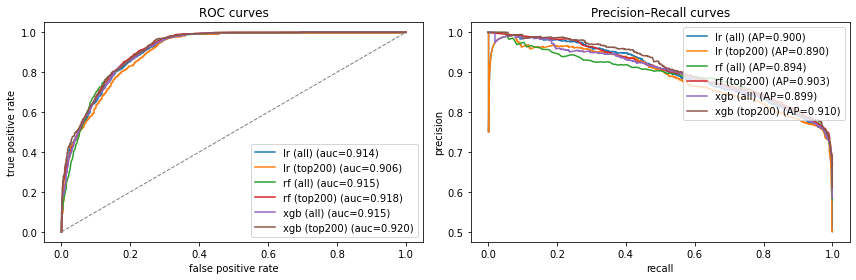

In [24]:
def plot_roc_pr(y_true, probs_dict):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    for name, p in probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, p)
        axes[0].plot(fpr, tpr, label=f"{name} (auc={auc(fpr,tpr):.3f})")
    axes[0].plot([0,1],[0,1],"--",lw=1,color="gray")
    axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
    axes[0].set_title("ROC curves"); axes[0].legend(loc="lower right")

    for name, p in probs_dict.items():
        pr, rc, _ = precision_recall_curve(y_true, p)
        ap = average_precision_score(y_true, p)
        axes[1].plot(rc, pr, label=f"{name} (AP={ap:.3f})")
    axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
    axes[1].set_title("Precision–Recall curves"); axes[1].legend(loc="upper right")

    plt.tight_layout(); plt.show()

probs_for_plots = {
    "lr (all)": prob_lr_all,
    f"lr (top{top_k})": prob_lr_k,
    "rf (all)": prob_rf_all,
    f"rf (top{top_k})": prob_rf_k,
}
if 'prob_xgb_all' in globals():
    probs_for_plots["xgb (all)"] = prob_xgb_all
if 'prob_xgb_k' in globals():
    probs_for_plots[f"xgb (top{top_k})"] = prob_xgb_k

plot_roc_pr(yte.values if hasattr(yte,'values') else yte, probs_for_plots)

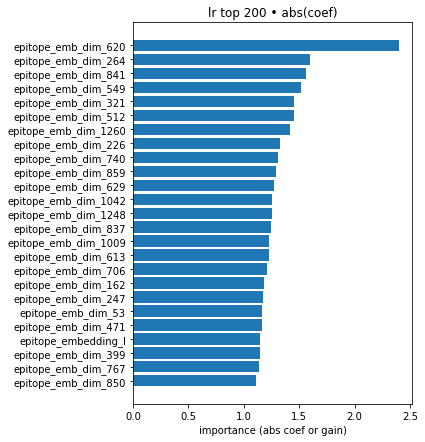

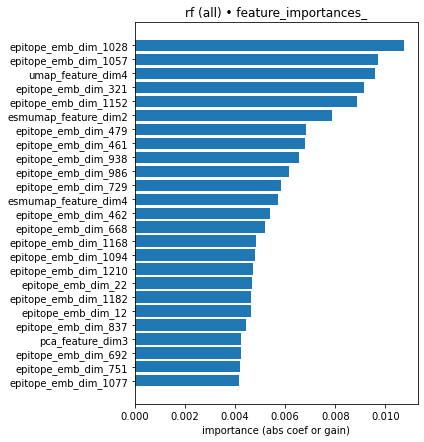

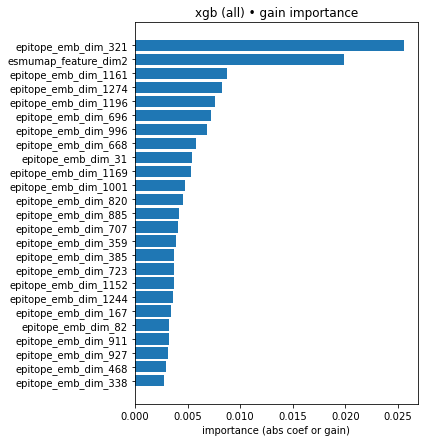

In [25]:
def bar_top_features(names, scores, title, k=25):
    order = np.argsort(-np.abs(scores))[:k]
    plt.figure(figsize=(6, max(3, k*0.25)))
    plt.barh(np.array(names)[order][::-1], np.array(scores)[order][::-1])
    plt.title(title); plt.xlabel("importance (abs coef or gain)"); plt.tight_layout(); plt.show()

lr_coef = pipe_lr_topk.named_steps['clf'].coef_.ravel()
bar_top_features(lr_top_features, np.abs(lr_coef), f"lr top {top_k} • abs(coef)")

bar_top_features(feature_cols, rf_all.feature_importances_, "rf (all) • feature_importances_")

if 'xgb_all' in globals():
    bar_top_features(feature_cols, xgb_all.feature_importances_, "xgb (all) • gain importance")

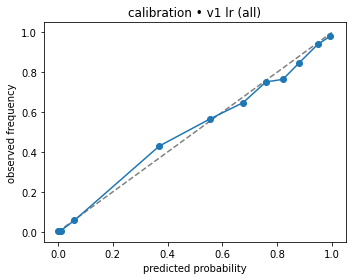

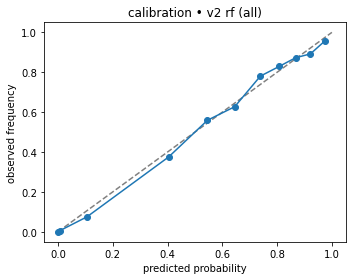

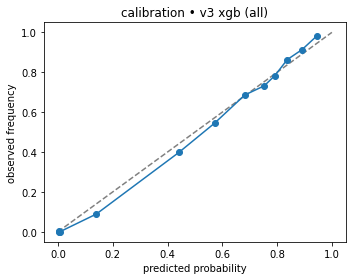

In [26]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, probs, title):
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=12, strategy="quantile")
    plt.figure(figsize=(5,4))
    plt.plot([0,1],[0,1],"--",color="gray")
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
    plt.title(title); plt.tight_layout(); plt.show()

plot_calibration(yte, prob_lr_all, "calibration • v1 lr (all)")
plot_calibration(yte, prob_rf_all, "calibration • v2 rf (all)")
if 'prob_xgb_all' in globals():
    plot_calibration(yte, prob_xgb_all, "calibration • v3 xgb (all)")

In [27]:
# Ablation Analysis Table

abl_rows = [
    ["Logistic Regression", metrics_lr_all["roc_auc"], metrics_lr_k["roc_auc"],
     metrics_lr_k["roc_auc"] - metrics_lr_all["roc_auc"],
     metrics_lr_all["f1"], metrics_lr_k["f1"], metrics_lr_k["f1"] - metrics_lr_all["f1"]],
    ["Random Forest", metrics_rf_all["roc_auc"], metrics_rf_k["roc_auc"],
     metrics_rf_k["roc_auc"] - metrics_rf_all["roc_auc"],
     metrics_rf_all["f1"], metrics_rf_k["f1"], metrics_rf_k["f1"] - metrics_rf_all["f1"]],
    ["XGBoost", metrics_xgb_all["roc_auc"], metrics_xgb_k["roc_auc"],
     metrics_xgb_k["roc_auc"] - metrics_xgb_all["roc_auc"],
     metrics_xgb_all["f1"], metrics_xgb_k["f1"], metrics_xgb_k["f1"] - metrics_xgb_all["f1"]],
]

abl_df = pd.DataFrame(
    abl_rows,
    columns=[
        "model",
        "roc_auc (all)",
        f"roc_auc (top {top_k})",
        "delta auc",
        "f1 (all)",
        f"f1 (top {top_k})",
        "delta f1"
    ]
)

abl_df.set_index("model", inplace=True)
abl_df = abl_df.round(3)

print("ablation analysis summary (all features vs top 200)")
display(abl_df)

ablation analysis summary (all features vs top 200)


,roc_auc (all),roc_auc (top 200),delta auc,f1 (all),f1 (top 200),delta f1
model,,,,,,
Logistic Regression,0.914,0.906,-0.007,0.844,0.841,-0.003
Random Forest,0.915,0.918,0.004,0.851,0.848,-0.003
XGBoost,0.915,0.920,0.005,0.850,0.854,0.004


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import FunctionTransformer

def make_selector(cols):
    return FunctionTransformer(lambda df: df[cols].values, validate=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
}

cv_rows = []

# logistic (top-k)
pipe_lr_cv = Pipeline([
    ("select", make_selector(lr_top_features)),
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2", solver="lbfgs", C=0.5, tol=1e-3, max_iter=1000,
        class_weight="balanced", random_state=random_state
    )),
])
res_lr = cross_validate(pipe_lr_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("logistic (top{0})".format(top_k), res_lr))

# random forest (top-k)
pipe_rf_cv = Pipeline([
    ("select", make_selector(rf_top_features)),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1,
        max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=random_state
    )),
])
res_rf = cross_validate(pipe_rf_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("random forest (top{0})".format(top_k), res_rf))

# xgboost (top-k)
pos_all = int(y.sum()); neg_all = int(len(y) - pos_all)
spw = (neg_all / pos_all) if pos_all else 1.0
pipe_xgb_cv = Pipeline([
    ("select", make_selector(xgb_top_features)),
    ("clf", XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.0, tree_method="hist",
        objective="binary:logistic", eval_metric="auc",
        n_jobs=-1, random_state=random_state, scale_pos_weight=spw
    )),
])
res_xgb = cross_validate(pipe_xgb_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("xgboost (top{0})".format(top_k), res_xgb))

# assemble summary table (mean ± std)
def mean_std(col):
    return f"{np.mean(col):.3f} ± {np.std(col):.3f}"

rows = []
for name, res in cv_rows:
    row = {
        "model": name,
        "roc_auc": mean_std(res["test_roc_auc"]),
        "f1": mean_std(res["test_f1"]),
        "accuracy": mean_std(res["test_accuracy"]),
        "precision": mean_std(res["test_precision"]),
        "recall": mean_std(res["test_recall"]),
    }
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index("model")
print("5-fold cross-validation (mean ± std)")
try:
    display(cv_summary)
except:
    print(cv_summary)

5-fold cross-validation (mean ± std)


,roc_auc,f1,accuracy,precision,recall
model,,,,,
logistic (top200),0.915 ± 0.002,0.851 ± 0.003,0.837 ± 0.003,0.782 ± 0.006,0.932 ± 0.009
random forest (top200),0.918 ± 0.001,0.849 ± 0.005,0.839 ± 0.005,0.802 ± 0.007,0.901 ± 0.012
xgboost (top200),0.921 ± 0.002,0.858 ± 0.004,0.845 ± 0.006,0.794 ± 0.008,0.932 ± 0.004


In [29]:
# failure analysis

auc_scores = {
    "xgb_topk": metrics_xgb_k["roc_auc"],
    "rf_topk": metrics_rf_k["roc_auc"],
    "lr_topk": metrics_lr_k["roc_auc"],
}
best_key = max(auc_scores, key=auc_scores.get)

if best_key == "xgb_topk":
    best_name = f"xgboost (top{top_k})"
    best_model = xgb_topk
    best_feats = xgb_top_features
elif best_key == "rf_topk":
    best_name = f"random forest (top{top_k})"
    best_model = rf_topk
    best_feats = rf_top_features
else:
    best_name = f"logistic (top{top_k})"
    best_model = pipe_lr_topk
    best_feats = lr_top_features

xte_best = xte[best_feats]
prob_best = best_model.predict_proba(xte_best)[:, 1]
yhat_best = (prob_best >= 0.5).astype(int)
mistakes = (yhat_best != yte.values)

test_index = xte.index.to_numpy()
mistake_index = test_index[mistakes]

fp_mask = (yte.values == 0) & (yhat_best == 1)
fn_mask = (yte.values == 1) & (yhat_best == 0)

fp_idx = np.where(fp_mask)[0]
ex_fp = fp_idx[np.argmax(prob_best[fp_idx])] if fp_idx.size > 0 else None

fn_idx = np.where(fn_mask)[0]
ex_fn = fn_idx[np.argmin(prob_best[fn_idx])] if fn_idx.size > 0 else None

if mistake_index.size > 0:
    mis_local_idx = np.where(mistakes)[0]
    ex_border = mis_local_idx[np.argmin(np.abs(prob_best[mis_local_idx] - 0.5))]
else:
    ex_border = None

chosen_local = [i for i in [ex_fp, ex_fn, ex_border] if i is not None]
chosen_global = [xte.index[i] for i in chosen_local]

nice_cols = [label_col, "vdjdb.score", "cdr3", "antigen.epitope", "gene", "species", "sequence"]
nice_cols = [c for c in nice_cols if c in df.columns]

k_show = min(8, len(best_feats))
cols_to_show = nice_cols + best_feats[:k_show]

fa_rows = df.loc[chosen_global, cols_to_show].copy()
fa_rows["pred_prob"] = prob_best[chosen_local]
fa_rows["pred_label"] = yhat_best[chosen_local]
fa_rows["true_label"] = yte.values[chosen_local]
fa_rows["error_type"] = ["FP" if yhat_best[i]==1 and yte.values[i]==0 else
                         "FN" if yhat_best[i]==0 and yte.values[i]==1 else
                         "misclass" for i in chosen_local]

print(f"failure analysis (best model: {best_name})")

display(fa_rows)

failure analysis (best model: xgboost (top200))


,binding,vdjdb.score,cdr3,antigen.epitope,gene,species,sequence,epitope_emb_dim_321,esmumap_feature_dim2,epitope_emb_dim_1161,epitope_emb_dim_1274,epitope_emb_dim_1196,epitope_emb_dim_696,epitope_emb_dim_996,epitope_emb_dim_668,pred_prob,pred_label,true_label,error_type
16860,0,0,CASTSRVGEAFF,HPVGEADYFEY,TRB,HomoSapiens,CASTSRVGEAFF,-0.075376,5.609195,0.221767,-0.224516,0.107942,0.059107,-0.040143,0.135187,0.991739,1,0,FP
6223,1,3,CASSYVGNTGELFF,SLLMWITQV,TRB,HomoSapiens,CASSYVGNTGELFF,0.122017,2.737688,-0.034854,-0.470558,0.147302,0.142504,0.077353,0.013639,0.004661,0,1,FN
11139,0,0,CASSLTNSPYEQYF,RAKFKQLL,TRB,HomoSapiens,CASSLTNSPYEQYF,0.088962,6.011186,0.030234,-0.359007,0.074203,-0.003938,-0.112395,-0.005425,0.500432,1,0,FP


In [30]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
score = "roc_auc"

# logistic regression:
pipe_lr_gs = Pipeline([
    ("select", make_selector(lr_top_features)),
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2", solver="lbfgs",
        class_weight="balanced", max_iter=800, random_state=random_state
    )),
])
param_grid_lr = {
    "clf__C": [0.3, 1.0, 3.0],
}
gs_lr = GridSearchCV(pipe_lr_gs, param_grid_lr, scoring=score, refit=True,
                     cv=cv3, n_jobs=-1, verbose=0, pre_dispatch="2*n_jobs")
gs_lr.fit(x, y)
best_lr = gs_lr.best_estimator_
print("best lr:", gs_lr.best_params_, "auc:", f"{gs_lr.best_score_:.3f}")

# random forest
pipe_rf_gs = Pipeline([
    ("select", make_selector(rf_top_features)),
    ("clf", RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=random_state
    )),
])
param_grid_rf = {
    "clf__n_estimators": [300],
    "clf__max_depth": [None, 20],
    "clf__min_samples_leaf": [1, 2],
}
gs_rf = GridSearchCV(pipe_rf_gs, param_grid_rf, scoring=score, refit=True,
                     cv=cv3, n_jobs=-1, verbose=0, pre_dispatch="2*n_jobs")
gs_rf.fit(x, y)
best_rf = gs_rf.best_estimator_
print("best rf:", gs_rf.best_params_, "auc:", f"{gs_rf.best_score_:.3f}")

# xgboost
pipe_xgb_gs = Pipeline([
    ("select", make_selector(xgb_top_features)),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", n_jobs=-1, random_state=random_state,
        scale_pos_weight=(len(y) - int(y.sum())) / max(int(y.sum()), 1),
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=0.0,
        n_estimators=400
    )),
])
param_grid_xgb = {
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1],
}
gs_xgb = GridSearchCV(pipe_xgb_gs, param_grid_xgb, scoring=score, refit=True,
                      cv=cv3, n_jobs=-1, verbose=0, pre_dispatch="2*n_jobs")
gs_xgb.fit(x, y)
best_xgb = gs_xgb.best_estimator_
print("best xgb:", gs_xgb.best_params_, "auc:", f"{gs_xgb.best_score_:.3f}")

best lr: {'clf__C': 3.0} auc: 0.914
best rf: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300} auc: 0.920
best xgb: {'clf__learning_rate': 0.05, 'clf__max_depth': 4} auc: 0.918


In [31]:
# compare baseline (top-k) vs tuned (grid search) on the test set

prob_lr_tuned = best_lr.predict_proba(xte)[:, 1]
prob_rf_tuned = best_rf.predict_proba(xte)[:, 1]
prob_xgb_tuned = best_xgb.predict_proba(xte)[:, 1]

metrics_lr_tuned = eval_metrics(yte, prob_lr_tuned)
metrics_rf_tuned = eval_metrics(yte, prob_rf_tuned)
metrics_xgb_tuned = eval_metrics(yte, prob_xgb_tuned)

cmp_rows = [
    ["logistic", "baseline", *[metrics_lr_k[k] for k in ["roc_auc","f1","accuracy","precision","recall"]]],
    ["logistic","tuned",*[metrics_lr_tuned[k] for k in ["roc_auc","f1","accuracy","precision","recall"]]],
    ["random forest","baseline", *[metrics_rf_k[k] for k in ["roc_auc","f1","accuracy","precision","recall"]]],
    ["random forest","tuned",*[metrics_rf_tuned[k] for k in ["roc_auc","f1","accuracy","precision","recall"]]],
    ["xgboost", "baseline", *[metrics_xgb_k[k] for k in ["roc_auc","f1","accuracy","precision","recall"]]],
    ["xgboost","tuned",*[metrics_xgb_tuned[k]for k in ["roc_auc","f1","accuracy","precision","recall"]]],
]
cmp_df = pd.DataFrame(
    cmp_rows,
    columns=["model","setting","roc_auc","f1","accuracy","precision","recall"]
)

def add_deltas(df):
    metric_keys = ["roc_auc","f1","accuracy","precision","recall"]
    wide = df.pivot_table(index="model", columns="setting", values=metric_keys)

    if ("baseline" not in wide.columns.get_level_values(1)) or ("tuned" not in wide.columns.get_level_values(1)):
        return df

    tuned = wide.xs("tuned", axis=1, level="setting")
    base  = wide.xs("baseline", axis=1, level="setting")
    delta = tuned[metric_keys].subtract(base[metric_keys], fill_value=0.0)

    delta_rows = []
    for m in delta.index:
        vals = [delta.loc[m, k] for k in metric_keys]
        delta_rows.append(["delta " + m, "tuned-baseline"] + vals)

    d = pd.DataFrame(delta_rows, columns=df.columns)
    return pd.concat([df, d], axis=0, ignore_index=True)

cmp_df = add_deltas(cmp_df)
cmp_df = cmp_df.set_index(["model","setting"]).round(4)

print("baseline vs tuned (test set) — with deltas")
display(cmp_df)

baseline vs tuned (test set) — with deltas


roc_auc      f1  accuracy  precision  \
model               setting                                                
logistic            baseline         0.9061  0.8410    0.8261     0.7746   
                    tuned            0.9132  0.8475    0.8330     0.7799   
random forest       baseline         0.9184  0.8482    0.8391     0.8027   
                    tuned            0.9892  0.9465    0.9435     0.8989   
xgboost             baseline         0.9198  0.8541    0.8399     0.7844   
                    tuned            0.9315  0.8656    0.8524     0.7942   
delta logistic      tuned-baseline   0.0071  0.0064    0.0069     0.0053   
delta random forest tuned-baseline   0.0708  0.0983    0.1044     0.0963   
delta xgboost       tuned-baseline   0.0117  0.0115    0.0125     0.0098   

                                    recall  
model               setting                 
logistic            baseline        0.9199  
                    tuned           0.9279  
random forest       baseline        0.8993  
                    tuned           0.9995  
xgboost             baseline        0.9374  
                    tuned           0.9512  
delta logistic      tuned-baseline  0.0080  
delta random forest tuned-baseline  0.1002  
delta xgboost       tuned-baseline  0.0138